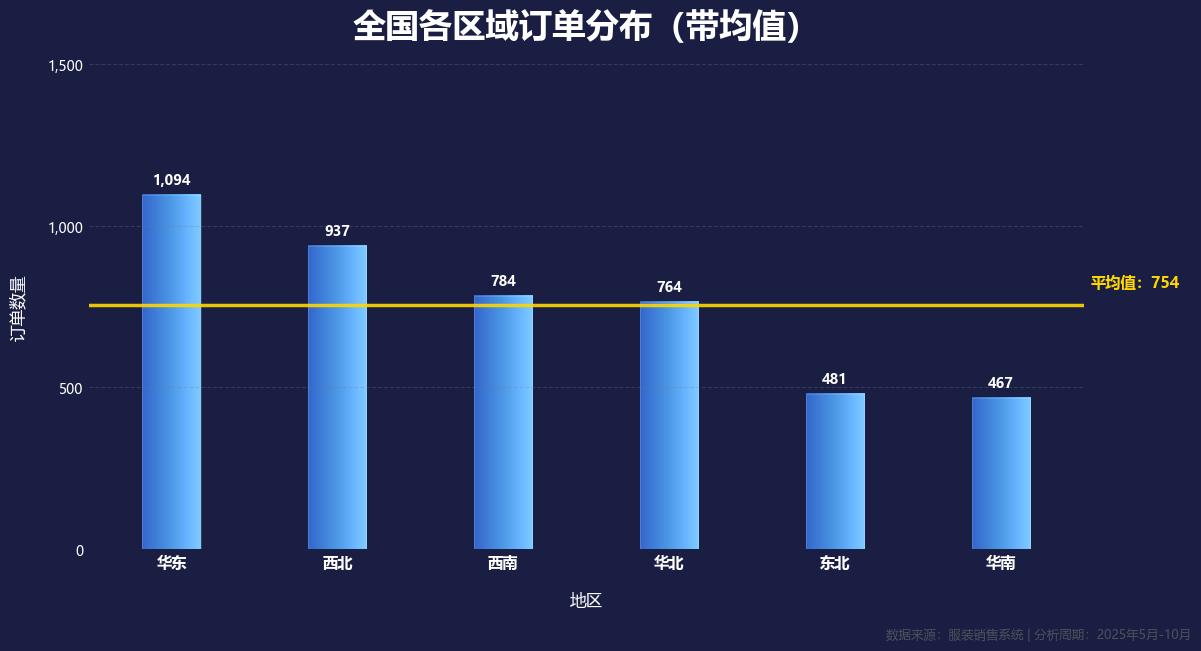

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 区域划分映射
REGION_MAPPING = {
    '华北': ['北京市', '天津市', '河北省', '山西省', '内蒙古自治区'],
    '华东': ['上海市', '江苏省', '浙江省', '安徽省', '福建省', '江西省', '山东省'],
    '华南': ['广东省', '广西壮族自治区', '海南省'],
    '华中': ['河南省', '湖北省', '湖南省'],
    '西南': ['重庆市', '四川省', '贵州省', '云南省', '西藏自治区'],
    '西北': ['陕西省', '甘肃省', '青海省', '宁夏回族自治区', '新疆维吾尔自治区'],
    '东北': ['辽宁省', '吉林省', '黑龙江省']
}

# 自定义蓝色渐变
def create_blue_gradient():
    colors = [
        (0.2, 0.4, 0.8),  # 深蓝色 (底部)
        (0.25, 0.5, 0.85),
        (0.3, 0.6, 0.9),
        (0.4, 0.7, 1.0),  # 亮蓝色 (顶部)
        (0.5, 0.8, 1.0)
    ]
    return LinearSegmentedColormap.from_list('custom_blue', colors, N=256)

# 生成渐变柱体
def add_gradient_bar(ax, x, height, width, cmap):
    # 创建渐变网格
    gradient = np.linspace(0, 1, 256).reshape(1, 256)
    
    # 柱体位置
    left = x - width/2
    right = x + width/2
    
    # 绘制渐变柱体
    ax.imshow(gradient, 
            aspect='auto',
            extent=[left, right, 0, height],
            cmap=cmap,
            interpolation='bilinear')
    
    # 添加柱体轮廓
    rect = Rectangle((left, 0), width, height, 
                    fill=False, 
                    edgecolor='white',
                    alpha=0.2,
                    linewidth=0.5)
    ax.add_patch(rect)

try:
    # 严格读取CSV文件
    df_orders = pd.read_csv('../../数据生成/erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['省份']
    for col in required_columns:
        if col not in df_orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 数据清洗
    if df_orders['省份'].isnull().all():
        raise ValueError("省份数据全部为空")
    
    # 清洗无效省份数据
    df_orders = df_orders[df_orders['省份'].notnull()]
    if df_orders.empty:
        raise ValueError("没有有效的省份数据")
    
    # 映射区域
    def map_region(province):
        for region, provinces in REGION_MAPPING.items():
            if province in provinces:
                return region
        return '其他'
    
    df_orders['区域'] = df_orders['省份'].apply(map_region)
    
    # 计算各区域订单量
    region_orders = df_orders.groupby('区域').size().reset_index(name='订单量')
    
    # 仅保留六大区域
    main_regions = ['华北', '华东', '华南', '东北', '西南', '西北']
    region_orders = region_orders[region_orders['区域'].isin(main_regions)]
    
    if region_orders.empty:
        raise ValueError("没有符合条件的区域数据")
    
    # 按订单量排序
    region_orders = region_orders.sort_values('订单量', ascending=False).reset_index(drop=True)
    
    # 计算平均值
    mean_value = region_orders['订单量'].mean()
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深蓝色背景
    ax.set_facecolor('#1A1E43')
    
    # 设置坐标轴
    ax.set_xlim(-0.5, len(region_orders) - 0.5)
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置网格线
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='#777b92')
    
    # 创建渐变
    blue_cmap = create_blue_gradient()
    
    # 设置柱子宽度
    width = 0.35
    
    # 准备数据
    x = list(range(len(region_orders)))
    
    # 绘制渐变柱体
    for i, (region, count) in enumerate(zip(region_orders['区域'], region_orders['订单量'])):
        add_gradient_bar(ax, x[i], count, width, blue_cmap)
        
        # 添加数据标注
        ax.annotate(
            f'{count:,}',
            xy=(x[i], count),
            xytext=(0, 5),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            color='white',
            fontweight='bold'
        )
    
    # 动态设置Y轴刻度
    max_val = region_orders['订单量'].max()
    
    # 计算刻度上限
    y_top = ((max_val // 500) + 1) * 500
    
    # 生成固定间隔的刻度
    y_ticks = np.arange(0, y_top + 500, 500)
    
    # 设置Y轴范围和刻度
    ax.set_ylim(0, y_top)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(x):,}' for x in y_ticks], 
                        color="#ffffff", fontsize=10)
    
    # 添加平均值线
    ax.axhline(y=mean_value, color='#FFD700', linewidth=2.5, linestyle='-', alpha=0.9)
    
    # 添加平均值标签
    ax.annotate(
        f'平均值：{int(mean_value):,}',
        xy=(len(region_orders)-0.5, mean_value),
        xytext=(5, 10),
        textcoords="offset points",
        ha='left',
        va='bottom',
        fontsize=11,
        color='#FFD700',
        fontweight='bold'
    )
    
    # 设置X轴
    ax.set_xticks(x)
    ax.set_xticklabels(region_orders['区域'], color="#ffffff", fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', length=0)
    
    # 隐藏X轴和Y轴的标签刻度
    ax.tick_params(axis='x', which='both', length=0)  # 隐藏X轴的刻度
    ax.tick_params(axis='y', which='both', length=0)  # 隐藏Y轴的刻度
    
    # 添加标题和标签
    plt.title('全国各区域订单分布（带均值）', fontsize=24, fontweight='bold', color="#ffffff", pad=20)
    plt.xlabel('地区', fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel('订单数量', fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加底部装饰
    plt.figtext(0.87, 0.03, 
                '数据来源：服装销售系统 | 分析周期：2025年5月-10月', 
                ha='center', 
                fontsize=9, 
                color='#666666',
                alpha=0.7)
    
    # 调整布局
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('全国各区域订单分布（带均值）.png', 
                dpi=300, 
                bbox_inches='tight',
                facecolor=fig.get_facecolor())
    
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析：



* 华东区域：
该区域的订单数量最高，达到1094个订单，显著高于平均值754，表明该区域具有较高的市场需求或业务活跃度。

* 西北区域：
订单数量为937个，略低于华东区域，但同样高于平均值，显示出该区域的市场潜力。

* 西南区域：
订单数量为784个，接近平均值，表明该区域的市场表现稳定。

* 华北区域：
订单数量为764个，略低于西南区域，显示出该区域的市场活跃度与西南地区相似。

* 东北区域：
订单数量为481个，低于平均值，显示出该区域的市场活跃度相对较低。

* 华南区域：
订单数量最少，为467个，显著低于平均值，可能反映了该区域的市场需求较低或市场渗透率不足。



# 结论：

从订单数量的地理分布来看，华东地区的市场表现最为突出，可能与该地区的经济发展水平、人口密度和消费习惯有关。西北和西南地区也显示出较强的市场潜力。相比之下，东北和华南地区的市场表现相对较弱，这可能与当地的经济发展状况、消费者行为或市场竞争程度有关。这些数据为进一步的市场分析和策略制定提供了基础，有助于理解不同区域的市场动态和消费者需求。